In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
# ตั้งค่าฟอนต์ภาษาไทยสำหรับ matplotlib (อาจต้องเปลี่ยนชื่อฟอนต์ตาม OS เช่น 'Tahoma', 'Cordia New', 'TH Sarabun New')
plt.rcParams['font.family'] = 'Tahoma'

class JobScheduling:
    def __init__(self):
        pass
    def _calculate_metrics(self, df):
        """ฟังก์ชันช่วยคำนวณ Completion Time (C), Lateness (L), Tardiness (T)"""
        df['เวลาที่งานออกจากเครื่อง (C)'] = df['เวลาในการผลิต (t)'].cumsum()
        if 'กำหนดส่ง (d)' in df.columns:
            df['เวลาส่งไม่ทัน (L)'] = df['เวลาที่งานออกจากเครื่อง (C)'] - df['กำหนดส่ง (d)']
            df['Tardiness (T)'] = df['เวลาส่งไม่ทัน (L)'].apply(lambda x: max(0, x))
        return df

    def spt(self, jobs_df):
        """Shortest Processing Time (SPT)"""
        df = jobs_df.sort_values(by='เวลาในการผลิต (t)').reset_index(drop=True)
        return self._calculate_metrics(df)

    def wspt(self, jobs_df):
        """Weighted Shortest Processing Time (WSPT)"""
        df = jobs_df.copy()
        df['t/w'] = df['เวลาในการผลิต (t)'] / df['ความสำคัญ (w)']
        df = df.sort_values(by=['t/w', 'เวลาในการผลิต (t)']).reset_index(drop=True)
        df['เวลาที่งานออกจากเครื่อง (C)'] = df['เวลาในการผลิต (t)'].cumsum()
        if 'กำหนดส่ง (d)' in df.columns:
            df['เวลาส่งไม่ทัน (L)'] = df['เวลาที่งานออกจากเครื่อง (C)'] - df['กำหนดส่ง (d)']
            df['Tardiness (T)'] = df['เวลาส่งไม่ทัน (L)'].apply(lambda x: max(0, x))
        return df

    def edd(self, jobs_df):
        """Earliest Due-Date (EDD)"""
        df = jobs_df.sort_values(by='กำหนดส่ง (d)').reset_index(drop=True)
        return self._calculate_metrics(df)

    def slack_time(self, jobs_df, t_now=0.0):
        """Slack Time"""
        df = jobs_df.copy()
        df['Slack Time (SL)'] = df['กำหนดส่ง (d)'] - t_now - df['เวลาในการผลิต (t)']
        df = df.sort_values(by=['Slack Time (SL)', 'กำหนดส่ง (d)']).reset_index(drop=True)
        return self._calculate_metrics(df)

    def hodgson_detailed(self, jobs_df):
        """Hodgson's Algorithm แบบแสดงผลลัพธ์ละเอียดทุกขั้นตอนตามสไลด์"""
        print("=== เริ่มต้นกระบวนการ Hodgson's Algorithm ===")
        print("เป้าหมาย: ทำให้จำนวนชิ้นงานที่ส่งไม่ทันมีน้อยที่สุด\n")
        
        # ขั้นตอนที่ 1: จัดลำดับงานตามกฎ EDD
        current_seq = jobs_df.sort_values(by='กำหนดส่ง (d)').to_dict('records')
        rejected_jobs = []
        step = 1
        
        from IPython.display import display # สำหรับแสดงตารางให้สวยงามใน Jupyter
        
        while True:
            # คำนวณเวลาที่งานออกจากเครื่อง (C) และ จำนวนชั่วโมงที่ส่งไม่ทัน (L)
            df_current = pd.DataFrame(current_seq)
            df_current['เวลาที่งานออกจากเครื่อง (C)'] = df_current['เวลาในการผลิต (t)'].cumsum()
            df_current['จำนวนชั่วโมงที่ส่งไม่ทัน (L)'] = df_current['เวลาที่งานออกจากเครื่อง (C)'] - df_current['กำหนดส่ง (d)']
            
            print(f"--- ขั้นตอนที่ {step} ---")
            display(df_current[['งาน', 'เวลาในการผลิต (t)', 'เวลาที่งานออกจากเครื่อง (C)', 'กำหนดส่ง (d)', 'จำนวนชั่วโมงที่ส่งไม่ทัน (L)']])
            
            # ขั้นตอนที่ 2: บ่งชี้งานที่ส่งไม่ทันงานแรก (L > 0)
            tardy_index = -1
            for i in range(len(df_current)):
                if df_current.loc[i, 'จำนวนชั่วโมงที่ส่งไม่ทัน (L)'] > 0:
                    tardy_index = i
                    break
            
            # ถ้าไม่พบงานที่ส่งไม่ทันเลย ให้หยุดกระบวนการ
            if tardy_index == -1:
                print(">> ไม่พบงานที่ส่งไม่ทันแล้ว (L <= 0 ทุกงาน) ยุติการคัดงานออก!")
                break
                
            first_tardy_job = current_seq[tardy_index]['งาน']
            print(f">> งานที่ส่งไม่ทันงานแรกคือ งานที่ {first_tardy_job} (พบในลำดับที่ {tardy_index + 1})")
            
            # ขั้นตอนที่ 3: เลือกงานที่ใช้เวลาในการผลิต (t) มากที่สุด ตั้งแต่งานแรกจนถึงงานที่ส่งไม่ทัน
            max_t_index = 0
            max_t = -1
            for i in range(tardy_index + 1):
                if current_seq[i]['เวลาในการผลิต (t)'] > max_t:
                    max_t = current_seq[i]['เวลาในการผลิต (t)']
                    max_t_index = i
            
            job_to_remove = current_seq[max_t_index]['งาน']
            print(f">> พิจารณางานตั้งแต่เริ่มต้นถึงงานที่ {first_tardy_job} พบว่างานที่ใช้เวลาผลิต (t) นานที่สุดคือ งานที่ {job_to_remove}")
            print(f">> นำ 'งานที่ {job_to_remove}' ออกจากการจัดลำดับ และคำนวณใหม่\n")
            
            # นำงานนั้นออกไปเก็บไว้ใน rejected_jobs
            rejected_jobs.append(current_seq.pop(max_t_index))
            step += 1
            
        # ขั้นตอนที่ 4: นำงานที่ถูกเลือกออกทั้งหมดไปต่อท้ายลำดับ
        print("\n=== ขั้นตอนที่ 4: สรุปผลลัพธ์สุดท้าย ===")
        print(f"งานที่ทำทันเวลา (ตามลำดับ): {[j['งาน'] for j in current_seq]}")
        print(f"งานที่ถูกคัดออกและนำไปต่อท้าย: {[j['งาน'] for j in rejected_jobs]}")
        
        # นำงานกลับมาต่อท้าย (ในตัวอย่างนี้นำมาต่อท้ายตามลำดับที่ถูกคัดออก)
        final_seq = current_seq + rejected_jobs
        df_final = pd.DataFrame(final_seq)
        
        # คำนวณพารามิเตอร์ของตารางสุดท้าย
        df_final['เวลาที่งานออกจากเครื่อง (C)'] = df_final['เวลาในการผลิต (t)'].cumsum()
        df_final['จำนวนชั่วโมงที่ส่งไม่ทัน (L)'] = df_final['เวลาที่งานออกจากเครื่อง (C)'] - df_final['กำหนดส่ง (d)']
        df_final['Tardiness (T)'] = df_final['จำนวนชั่วโมงที่ส่งไม่ทัน (L)'].apply(lambda x: max(0, x))
        
        # print("\nตารางลำดับงานสุดท้าย (พร้อมคำนวณ Tardiness):")
        # display(df_final[['งาน', 'เวลาในการผลิต (t)', 'เวลาที่งานออกจากเครื่อง (C)', 'กำหนดส่ง (d)', 'จำนวนชั่วโมงที่ส่งไม่ทัน (L)', 'Tardiness (T)']])
        return self._calculate_metrics(df_final)

    def parallel_machine(self, jobs_df, m_machines, rule='SPT'):
        """Parallel Processors แบบอัปเดตกฎ Tie-breaking ครบถ้วน"""
        
        # ขั้นตอนที่ 1: จัดลำดับงานทั้งหมด
        if rule == 'SPT':
            # เรียง t น้อยไปมาก, ถ้าเท่ากันให้ i น้อยไปมาก
            jobs = jobs_df.sort_values(by=['เวลาในการผลิต (t)', 'งาน']).to_dict('records')
        elif rule == 'LPT':
            # เรียง t มากไปน้อย, ถ้าเท่ากันให้ i น้อยไปมาก
            jobs = jobs_df.sort_values(by=['เวลาในการผลิต (t)', 'งาน'], ascending=[False, True]).to_dict('records')
        elif rule == 'EDD':
            # เรียง d น้อยไปมาก, ถ้าเท่ากันให้ i น้อยไปมาก
            jobs = jobs_df.sort_values(by=['กำหนดส่ง (d)', 'งาน']).to_dict('records')
            
        machines = [{'m_id': i+1, 'time': 0, 'jobs': []} for i in range(m_machines)]
        
        # ขั้นตอนที่ 2: มอบหมายงานให้เครื่องจักรที่ว่างที่สุด
        for job in jobs:
            # ใช้ (x['time'], x['m_id']) เพื่อบังคับว่าถ้าเวลาว่างเท่ากัน ให้เลือกเครื่องจักรหมายเลขน้อยกว่าเสมอ
            min_machine = min(machines, key=lambda x: (x['time'], x['m_id']))
            min_machine['jobs'].append(job)
            min_machine['time'] += job['เวลาในการผลิต (t)']
            
        # ขั้นตอนที่ 3: สลับลำดับงานภายในแต่ละเครื่องจักร (เฉพาะกฎ SPT+LPT)
        if rule == 'LPT':
            for m in machines:
                # จัดเรียงงานภายในเครื่องนั้นๆ ใหม่ด้วย SPT (t น้อยไปมาก, i น้อยไปมาก)
                m['jobs'] = sorted(m['jobs'], key=lambda x: (x['เวลาในการผลิต (t)'], x['งาน']))
                
        # สร้าง Dataframe สรุปผล
        result = []
        for m in machines:
            for j in m['jobs']:
                result.append({'เครื่องจักร': m['m_id'], 'งาน': j['งาน'], 't': j['เวลาในการผลิต (t)']})
        return pd.DataFrame(result)
    
    def johnson_rule(self, jobs_df):
        """Johnson's Rule for 2 Serial Processors"""
        jobs = jobs_df.to_dict('records')
        seq_front = []
        seq_back = []
        
        while jobs:
            # หา min time ทั้งหมด
            min_t = float('inf')
            min_job_idx = -1
            is_machine_1 = True
            
            for i, job in enumerate(jobs):
                if job['M1'] < min_t:
                    min_t = job['M1']
                    min_job_idx = i
                    is_machine_1 = True
                if job['M2'] < min_t:
                    min_t = job['M2']
                    min_job_idx = i
                    is_machine_1 = False
                    
            target_job = jobs.pop(min_job_idx)
            if is_machine_1:
                seq_front.append(target_job)
            else:
                seq_back.insert(0, target_job)
                
        final_seq = seq_front + seq_back
        return pd.DataFrame(final_seq)

In [2]:
import matplotlib.pyplot as plt

# ตั้งค่าฟอนต์ภาษาไทย (เปลี่ยนชื่อฟอนต์ได้ตามเครื่องที่ใช้ เช่น 'Tahoma', 'Cordia New')
plt.rcParams['font.family'] = 'Tahoma' 

def plot_parallel_gantt(self, df_result, title="แผนภูมิแกนต์ (Gantt Chart)"):
    """ฟังก์ชันวาดกราฟ Gantt Chart สำหรับ Parallel Machine (เติม self แล้ว)"""
    fig, ax = plt.subplots(figsize=(10, 4))
    
    machines = sorted(df_result['เครื่องจักร'].unique())
    max_c = 0  
    sum_c = 0  
    num_jobs = len(df_result)
    
    for m in machines:
        m_jobs = df_result[df_result['เครื่องจักร'] == m]
        current_time = 0
        
        for _, row in m_jobs.iterrows():
            start = current_time
            duration = row['t']
            end = start + duration
            job_id = row['งาน']
            
            ax.barh(m, duration, left=start, height=0.6, edgecolor='black', color='lightgray')
            ax.text(start + duration / 2, m, str(job_id), ha='center', va='center', color='black', fontsize=11)
            
            current_time = end
            sum_c += end
            if end > max_c:
                max_c = end

    ax.set_yticks(machines)
    ax.set_ylabel('เครื่องจักร', fontsize=12)
    ax.set_xlabel('เวลา', fontsize=12)
    
    ax.set_xticks(range(0, int(max_c) + 2, 2))
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    ax.set_title(title, fontsize=14, pad=15)
    
    ms = max_c
    f_bar = sum_c / num_jobs
    
    # แก้การแสดงผลข้อความด้านขวาให้ใช้ฟอร์แมตสตริงธรรมดา
    summary_text = f"Mean Flow Time = {f_bar:.1f} ชั่วโมง\nMake Span = {ms:.0f} ชั่วโมง"
    plt.text(max_c + 0.5, machines[len(machines)//2], summary_text, 
             fontsize=12, va='center', bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# แทรกฟังก์ชันที่แก้ไขแล้วกลับเข้าไปในคลาส
JobScheduling.plot_parallel_gantt = plot_parallel_gantt

In [3]:
scheduler = JobScheduling()

# ข้อมูลจากตาราง 7.4 และ 7.6
data_single = pd.DataFrame({
    'งาน': [1, 2, 3, 4, 5, 6, 7, 8],
    'เวลาในการผลิต (t)': [5, 8, 6, 3, 10, 14, 7, 3],
    'กำหนดส่ง (d)': [15, 10, 15, 25, 20, 40, 45, 50],
    'ความสำคัญ (w)': [1, 2, 3, 1, 2, 3, 2, 1] # จากตาราง 7.8
})

print("=== ตัวอย่าง 7.2 & 7.3: กฎ SPT ===")
display(scheduler.spt(data_single))

print("\n=== ตัวอย่าง 7.4: กฎ WSPT ===")
display(scheduler.wspt(data_single))

print("\n=== ตัวอย่าง 7.5: กฎ EDD ===")
display(scheduler.edd(data_single))

print("\n=== ตัวอย่าง 7.6: กฎ Slack Time (T_NOW = 0) ===")
display(scheduler.slack_time(data_single))

print("\n=== ตัวอย่าง 7.7: Hodgson's Algorithm ===")
display(scheduler.hodgson_detailed(data_single))


=== ตัวอย่าง 7.2 & 7.3: กฎ SPT ===


,งาน,เวลาในการผลิต (t),กำหนดส่ง (d),ความสำคัญ (w),เวลาที่งานออกจากเครื่อง (C),เวลาส่งไม่ทัน (L),Tardiness (T)
0,4,3,25,1,3,-22,0
1,8,3,50,1,6,-44,0
2,1,5,15,1,11,-4,0
3,3,6,15,3,17,2,2
4,7,7,45,2,24,-21,0
5,2,8,10,2,32,22,22
6,5,10,20,2,42,22,22
7,6,14,40,3,56,16,16



=== ตัวอย่าง 7.4: กฎ WSPT ===


,งาน,เวลาในการผลิต (t),กำหนดส่ง (d),ความสำคัญ (w),t/w,เวลาที่งานออกจากเครื่อง (C),เวลาส่งไม่ทัน (L),Tardiness (T)
0,3,6,15,3,2.000000,6,-9,0
1,4,3,25,1,3.000000,9,-16,0
2,8,3,50,1,3.000000,12,-38,0
3,7,7,45,2,3.500000,19,-26,0
4,2,8,10,2,4.000000,27,17,17
5,6,14,40,3,4.666667,41,1,1
6,1,5,15,1,5.000000,46,31,31
7,5,10,20,2,5.000000,56,36,36



=== ตัวอย่าง 7.5: กฎ EDD ===


...

,งาน,เวลาในการผลิต (t),เวลาที่งานออกจากเครื่อง (C),กำหนดส่ง (d),จำนวนชั่วโมงที่ส่งไม่ทัน (L)
0,1,5,5,15,-10
1,3,6,11,15,-4
2,5,10,21,20,1
3,4,3,24,25,-1
4,6,14,38,40,-2
5,7,7,45,45,0
6,8,3,48,50,-2


>> งานที่ส่งไม่ทันงานแรกคือ งานที่ 5 (พบในลำดับที่ 3)
>> พิจารณางานตั้งแต่เริ่มต้นถึงงานที่ 5 พบว่างานที่ใช้เวลาผลิต (t) นานที่สุดคือ งานที่ 5
>> นำ 'งานที่ 5' ออกจากการจัดลำดับ และคำนวณใหม่

--- ขั้นตอนที่ 3 ---


,งาน,เวลาในการผลิต (t),เวลาที่งานออกจากเครื่อง (C),กำหนดส่ง (d),จำนวนชั่วโมงที่ส่งไม่ทัน (L)
0,1,5,5,15,-10
1,3,6,11,15,-4
2,4,3,14,25,-11
3,6,14,28,40,-12
4,7,7,35,45,-10
5,8,3,38,50,-12


>> ไม่พบงานที่ส่งไม่ทันแล้ว (L <= 0 ทุกงาน) ยุติการคัดงานออก!

=== ขั้นตอนที่ 4: สรุปผลลัพธ์สุดท้าย ===
งานที่ทำทันเวลา (ตามลำดับ): [1, 3, 4, 6, 7, 8]
งานที่ถูกคัดออกและนำไปต่อท้าย: [2, 5]


,งาน,เวลาในการผลิต (t),กำหนดส่ง (d),ความสำคัญ (w),เวลาที่งานออกจากเครื่อง (C),จำนวนชั่วโมงที่ส่งไม่ทัน (L),Tardiness (T),เวลาส่งไม่ทัน (L)
0,1,5,15,1,5,-10,0,-10
1,3,6,15,3,11,-4,0,-4
2,4,3,25,1,14,-11,0,-11
3,6,14,40,3,28,-12,0,-12
4,7,7,45,2,35,-10,0,-10
5,8,3,50,1,38,-12,0,-12
6,2,8,10,2,46,36,36,36
7,5,10,20,2,56,36,36,36



=== ตัวอย่าง 7.8: Parallel SPT (3 เครื่อง) ===


,เครื่องจักร,งาน,t
0,1,6,2
1,1,7,3
2,1,8,5
3,1,4,8
4,2,10,2
5,2,9,4
6,2,2,6
7,3,3,3
8,3,1,5
9,3,5,7


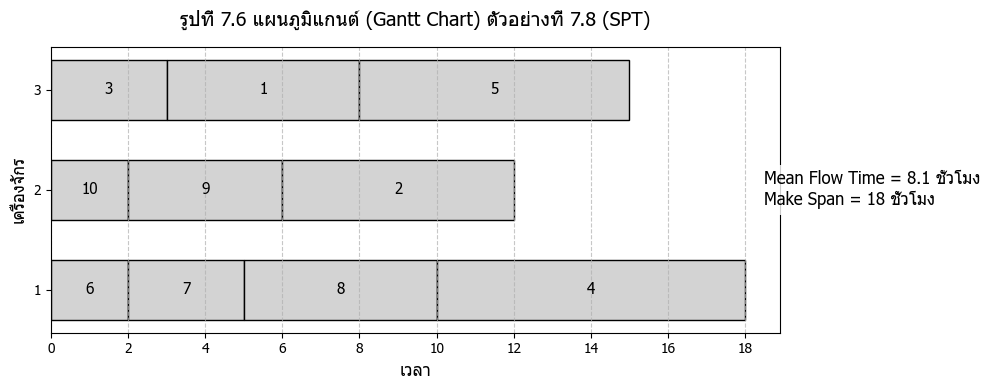


=== ตัวอย่าง 7.9: Parallel SPT+LPT (3 เครื่อง) ===


,เครื่องจักร,งาน,t
0,1,7,3
1,1,9,4
2,1,4,8
3,2,6,2
4,2,10,2
5,2,8,5
6,2,5,7
7,3,3,3
8,3,1,5
9,3,2,6


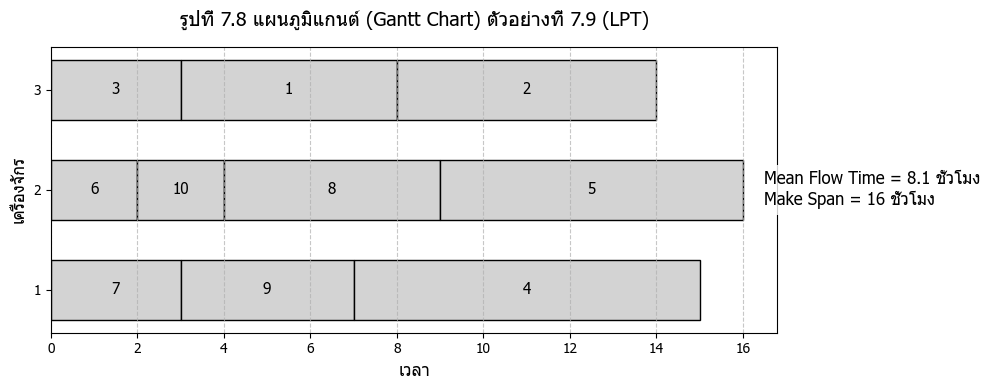

In [4]:
# ข้อมูลตัวอย่าง Parallel Machine (ตาราง 7.16 & 7.19)
data_parallel = pd.DataFrame({
    'งาน': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'เวลาในการผลิต (t)': [5, 6, 3, 8, 7, 2, 3, 5, 4, 2],
    'กำหนดส่ง (d)': [8, 9, 14, 12, 11, 5, 8, 10, 15, 7]
})

print("\n=== ตัวอย่าง 7.8: Parallel SPT (3 เครื่อง) ===")
df_spt_result = scheduler.parallel_machine(data_parallel, m_machines=3, rule='SPT')
display(df_spt_result)

# เรียกใช้ฟังก์ชันแสดงกราฟ
scheduler.plot_parallel_gantt(df_spt_result, title="รูปที่ 7.6 แผนภูมิแกนต์ (Gantt Chart) ตัวอย่างที่ 7.8 (SPT)")

print("\n=== ตัวอย่าง 7.9: Parallel SPT+LPT (3 เครื่อง) ===")
df_lpt_result = scheduler.parallel_machine(data_parallel, m_machines=3, rule='LPT')
display(df_lpt_result)

# เรียกใช้ฟังก์ชันแสดงกราฟ
scheduler.plot_parallel_gantt(df_lpt_result, title="รูปที่ 7.8 แผนภูมิแกนต์ (Gantt Chart) ตัวอย่างที่ 7.9 (LPT)")



=== ตัวอย่าง 7.10: Parallel EDD (3 เครื่อง) ===


,เครื่องจักร,งาน,t
0,1,6,2
1,1,7,3
2,1,8,5
3,1,3,3
4,2,10,2
5,2,2,6
6,2,4,8
7,3,1,5
8,3,5,7
9,3,9,4


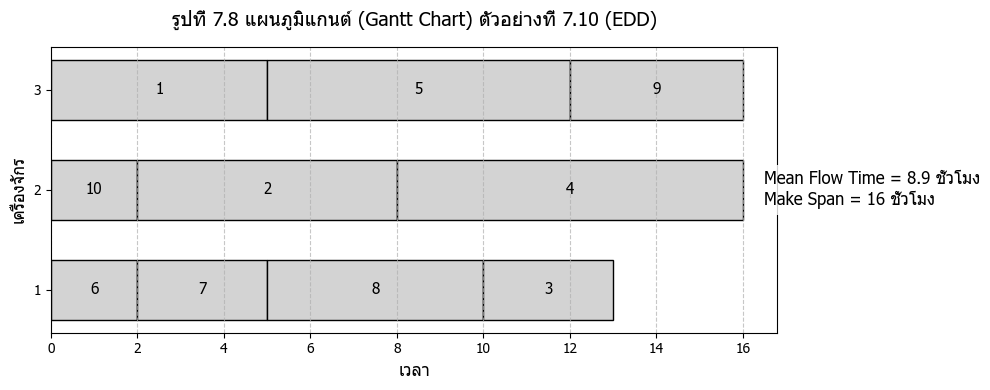

In [5]:
print("\n=== ตัวอย่าง 7.10: Parallel EDD (3 เครื่อง) ===")
df_edd_result = scheduler.parallel_machine(data_parallel, m_machines=3, rule='EDD')
display(df_edd_result)

# เรียกใช้ฟังก์ชันแสดงกราฟ
scheduler.plot_parallel_gantt(df_edd_result, title="รูปที่ 7.8 แผนภูมิแกนต์ (Gantt Chart) ตัวอย่างที่ 7.10 (EDD)")


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def johnson_detailed(self, jobs_df):
    """ฟังก์ชันคำนวณ Johnson's Rule แบบ Step-by-step"""
    print("=== เริ่มต้นกระบวนการ Johnson's Rule (แสดงทีละขั้นตอน) ===")
    jobs = jobs_df.to_dict('records')
    seq_front = []
    seq_back = []
    step = 1
    
    while jobs:
        # 1. หาเวลาที่น้อยที่สุดในงานที่เหลือทั้งหมด
        min_t = min(min(j['M1'], j['M2']) for j in jobs)
        
        # 2. คัดแยกกลุ่มงานที่มีเวลาเท่ากับ min_t บน M1 และ M2
        m1_candidates = [j for j in jobs if j['M1'] == min_t]
        m2_candidates = [j for j in jobs if j['M2'] == min_t]
        
        # 3. ตัดสินใจเลือกงาน (Tie-breaking เพื่อให้ตรงกับในหนังสือเป๊ะๆ)
        if m1_candidates:
            # ถ้าเจอ min_t ใน M1 ให้เลือกงานที่มีเวลา M2 "มากที่สุด" ผลักมาทำก่อนเป็นลำดับแรกสุด
            target_job = sorted(m1_candidates, key=lambda x: x['M2'], reverse=True)[0]
            is_m1 = True
        else:
            # ถ้าเจอ min_t ใน M2 ให้เลือกงานที่มีเวลา M1 "มากที่สุด" ผลักไปทำท้ายสุดก่อน
            target_job = sorted(m2_candidates, key=lambda x: x['M1'], reverse=True)[0]
            is_m1 = False
            
        job_name = target_job['งาน']
        jobs.remove(target_job)
        
        print(f"--- ขั้นตอนที่ {step} ---")
        print(f">> เวลาต่ำสุดที่พบคือ {min_t} ชั่วโมง")
        if is_m1:
            seq_front.append(target_job)
            print(f">> เลือกงาน {job_name} (เจอจุดต่ำสุดที่เครื่อง 1) -> นำไปจัดไว้ ลำดับหน้าสุดที่ว่างอยู่")
        else:
            seq_back.insert(0, target_job)
            print(f">> เลือกงาน {job_name} (เจอจุดต่ำสุดที่เครื่อง 2) -> นำไปจัดไว้ ลำดับท้ายสุดที่ว่างอยู่")
            
        print(f">> ลำดับชั่วคราว: {[j['งาน'] for j in seq_front]} ... {[j['งาน'] for j in seq_back]}\n")
        step += 1
        
    final_seq = seq_front + seq_back
    print("=== สรุปลำดับงานสุดท้าย (Final Sequence) ===")
    print([j['งาน'] for j in final_seq], "\n")
    
    # --- คำนวณเวลา Start/End เพื่อใช้วาด Gantt Chart ---
    df_final = pd.DataFrame(final_seq)
    start_m1, start_m2 = [], []
    end_m1, end_m2 = [], []
    curr_m1, curr_m2 = 0, 0
    
    for _, row in df_final.iterrows():
        # เครื่อง 1 เริ่มทำงานได้ทันทีที่เครื่อง 1 ว่าง
        s_m1 = curr_m1
        e_m1 = s_m1 + row['M1']
        start_m1.append(s_m1)
        end_m1.append(e_m1)
        curr_m1 = e_m1
        
        # เครื่อง 2 จะเริ่มได้ก็ต่อเมื่อ "เครื่อง 1 ทำชิ้นนั้นเสร็จแล้ว" และ "เครื่อง 2 ว่าง"
        s_m2 = max(e_m1, curr_m2)
        e_m2 = s_m2 + row['M2']
        start_m2.append(s_m2)
        end_m2.append(e_m2)
        curr_m2 = e_m2
        
    df_final['Start_M1'] = start_m1
    df_final['End_M1'] = end_m1
    df_final['Start_M2'] = start_m2
    df_final['End_M2'] = end_m2
    
    return df_final

def plot_johnson_gantt(self, df_final, title="รูปที่ 7.8 แผนภูมิแกนต์ (Gantt Chart) ตัวอย่างที่ 7.11"):
    """ฟังก์ชันวาดกราฟ Gantt Chart แบบอนุกรม (Serial Processors)"""
    fig, ax = plt.subplots(figsize=(12, 4))
    
    for _, row in df_final.iterrows():
        job_id = row['งาน']
        
        # วาดแท่งเครื่องที่ 1
        ax.barh(1, row['M1'], left=row['Start_M1'], edgecolor='black', color='lightgray', height=0.6)
        ax.text(row['Start_M1'] + row['M1']/2, 1, str(job_id), ha='center', va='center', color='black', fontsize=11)
        
        # วาดแท่งเครื่องที่ 2
        ax.barh(2, row['M2'], left=row['Start_M2'], edgecolor='black', color='silver', height=0.6)
        ax.text(row['Start_M2'] + row['M2']/2, 2, str(job_id), ha='center', va='center', color='black', fontsize=11)
        
    ax.set_yticks([1, 2])
    ax.set_yticklabels(['1', '2'])
    ax.set_ylabel('เครื่องจักร', fontsize=12)
    ax.set_xlabel('เวลา', fontsize=12)
    
    makespan = int(df_final['End_M2'].max())
    
    # วาดเส้น Grid ตามสไลด์
    ax.set_xticks(range(0, makespan + 2, 2))
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    ax.set_title(title, fontsize=14, pad=15)
    
    # สรุปผล
    summary_text = f"เวลาที่ต้องใช้ทั้งหมด\n($M_s$) = {makespan} ชั่วโมง"
    plt.text(makespan + 1, 1.5, summary_text, fontsize=12, va='center', 
             bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# แทรกฟังก์ชันลงไปในคลาส
JobScheduling.johnson_detailed = johnson_detailed
JobScheduling.plot_johnson_gantt = plot_johnson_gantt

>> รันอัลกอริทึมเพื่อหาลำดับงานทีละขั้นตอน
=== เริ่มต้นกระบวนการ Johnson's Rule (แสดงทีละขั้นตอน) ===
--- ขั้นตอนที่ 1 ---
>> เวลาต่ำสุดที่พบคือ 2 ชั่วโมง
>> เลือกงาน 3 (เจอจุดต่ำสุดที่เครื่อง 1) -> นำไปจัดไว้ ลำดับหน้าสุดที่ว่างอยู่
>> ลำดับชั่วคราว: [3] ... []

--- ขั้นตอนที่ 2 ---
>> เวลาต่ำสุดที่พบคือ 2 ชั่วโมง
>> เลือกงาน 2 (เจอจุดต่ำสุดที่เครื่อง 2) -> นำไปจัดไว้ ลำดับท้ายสุดที่ว่างอยู่
>> ลำดับชั่วคราว: [3] ... [2]

--- ขั้นตอนที่ 3 ---
>> เวลาต่ำสุดที่พบคือ 2 ชั่วโมง
>> เลือกงาน 8 (เจอจุดต่ำสุดที่เครื่อง 2) -> นำไปจัดไว้ ลำดับท้ายสุดที่ว่างอยู่
>> ลำดับชั่วคราว: [3] ... [8, 2]

--- ขั้นตอนที่ 4 ---
>> เวลาต่ำสุดที่พบคือ 3 ชั่วโมง
>> เลือกงาน 1 (เจอจุดต่ำสุดที่เครื่อง 1) -> นำไปจัดไว้ ลำดับหน้าสุดที่ว่างอยู่
>> ลำดับชั่วคราว: [3, 1] ... [8, 2]

--- ขั้นตอนที่ 5 ---
>> เวลาต่ำสุดที่พบคือ 4 ชั่วโมง
>> เลือกงาน 10 (เจอจุดต่ำสุดที่เครื่อง 2) -> นำไปจัดไว้ ลำดับท้ายสุดที่ว่างอยู่
>> ลำดับชั่วคราว: [3, 1] ... [10, 8, 2]

--- ขั้นตอนที่ 6 ---
>> เวลาต่ำสุดที่พบคือ 4 ชั่วโมง
>> เลือกงาน

,งาน,M1,M2,Start_M1,End_M1,Start_M2,End_M2
0,3,2,8,0,2,2,10
1,1,3,5,2,5,10,15
2,6,5,9,5,10,15,24
3,9,6,8,10,16,24,32
4,5,6,6,16,22,32,38
5,4,7,6,22,29,38,44
6,7,5,4,29,34,44,48
7,10,10,4,34,44,48,52
8,8,3,2,44,47,52,54
9,2,6,2,47,53,54,56



>> วาด Gantt Chart


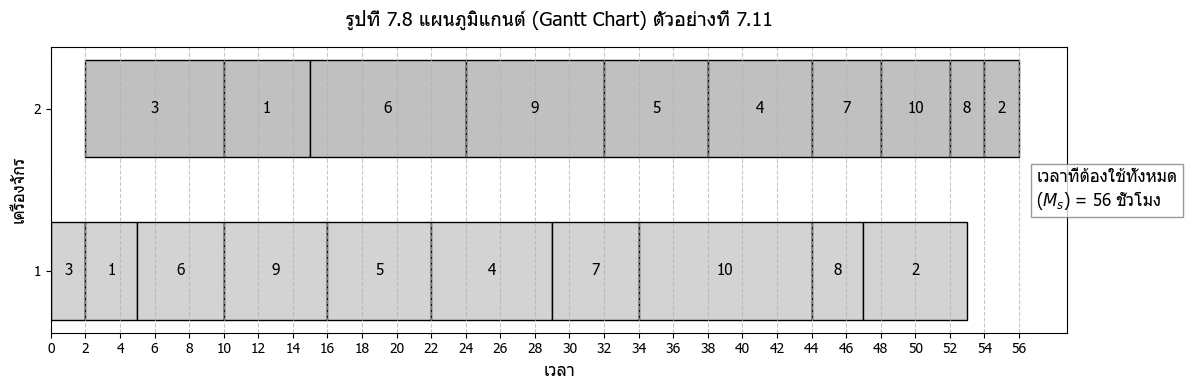

In [7]:
scheduler = JobScheduling()

# ข้อมูลงานแบบกระบวนการอนุกรม จากตารางที่ 7.21
data_johnson = pd.DataFrame({
    'งาน': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'M1': [3, 6, 2, 7, 6, 5, 5, 3, 6, 10],
    'M2': [5, 2, 8, 6, 6, 9, 4, 2, 8, 4]
})

print(">> รันอัลกอริทึมเพื่อหาลำดับงานทีละขั้นตอน")
df_johnson_result = scheduler.johnson_detailed(data_johnson)

# พิมพ์ตารางผลลัพธ์เพื่อดูรายละเอียดว่าแต่ละงาน เริ่ม/จบ กี่โมง
print("ตารางเวลา Start/End ของแต่ละงานบนเครื่องจักร:")
display(df_johnson_result[['งาน', 'M1', 'M2', 'Start_M1', 'End_M1', 'Start_M2', 'End_M2']])

print("\n>> วาด Gantt Chart")
scheduler.plot_johnson_gantt(df_johnson_result)

# final 2020

## 3

In [8]:
scheduler = JobScheduling()

# ข้อมูลจากตาราง 7.4 และ 7.6
data_single = pd.DataFrame({
    'งาน': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'เวลาในการผลิต (t)': [6, 4, 3, 3, 5, 3, 4, 4, 6, 3],
    'กำหนดส่ง (d)': [10, 9, 15, 14, 12, 5, 7, 10, 15, 11],
    'ความสำคัญ (w)': [1, 2, 3, 1, 2, 3, 2, 1, 2, 3] # จากตาราง 7.8
})

print("\n=== ตัวอย่าง 7.6: กฎ Slack Time (T_NOW = 0) ===")
display(scheduler.slack_time(data_single))



=== ตัวอย่าง 7.6: กฎ Slack Time (T_NOW = 0) ===


,งาน,เวลาในการผลิต (t),กำหนดส่ง (d),ความสำคัญ (w),Slack Time (SL),เวลาที่งานออกจากเครื่อง (C),เวลาส่งไม่ทัน (L),Tardiness (T)
0,6,3,5,3,2.0,3,-2,0
1,7,4,7,2,3.0,7,0,0
2,1,6,10,1,4.0,13,3,3
3,2,4,9,2,5.0,17,8,8
4,8,4,10,1,6.0,21,11,11
5,5,5,12,2,7.0,26,14,14
6,10,3,11,3,8.0,29,18,18
7,9,6,15,2,9.0,35,20,20
8,4,3,14,1,11.0,38,24,24
9,3,3,15,3,12.0,41,26,26


## 4


=== ตัวอย่าง 7.9: Parallel SPT+LPT (3 เครื่อง) ===


,เครื่องจักร,งาน,t
0,1,7,1
1,1,3,3
2,1,1,6
3,1,8,12
4,2,2,5
5,2,5,7
6,2,6,10
7,3,9,4
8,3,10,8
9,3,4,9


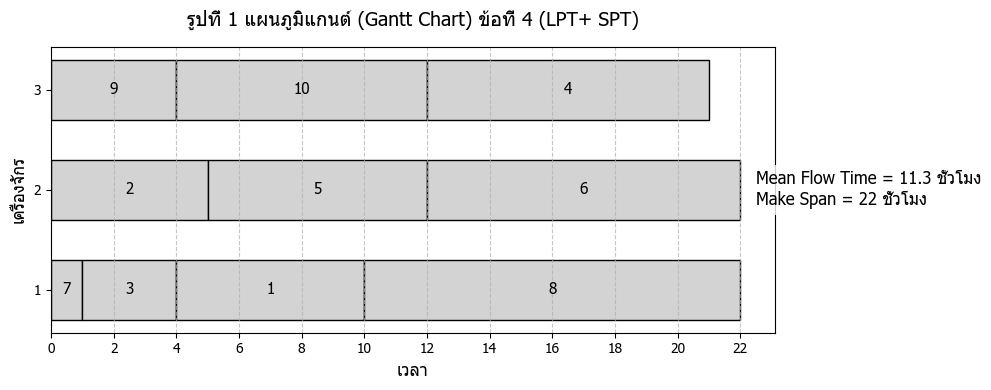

In [9]:
# ข้อมูลตัวอย่าง Parallel Machine (ตาราง 7.16 & 7.19)
data_parallel = pd.DataFrame({
    'งาน': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'เวลาในการผลิต (t)': [6, 5, 3, 9, 7, 10, 1, 12, 4, 8],
    'กำหนดส่ง (d)': [6, 9, 14, 12, 11, 5, 8, 10, 15, 7]
})

print("\n=== ตัวอย่าง 7.9: Parallel SPT+LPT (3 เครื่อง) ===")
df_lpt_result = scheduler.parallel_machine(data_parallel, m_machines=3, rule='LPT')
display(df_lpt_result)

# เรียกใช้ฟังก์ชันแสดงกราฟ
scheduler.plot_parallel_gantt(df_lpt_result, title="รูปที่ 1 แผนภูมิแกนต์ (Gantt Chart) ข้อที่ 4 (LPT+ SPT)")


# final 2021

## 3

In [10]:
scheduler = JobScheduling()

# ข้อมูลจากตาราง 7.4 และ 7.6
data_single = pd.DataFrame({
    'งาน': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'เวลาในการผลิต (t)': [6, 4, 8, 9, 5, 3, 4, 7, 6, 5],
    'กำหนดส่ง (d)': [30, 42, 23, 13, 47, 38, 50, 55, 24, 10],
    'ความสำคัญ (w)': [1, 2, 3, 1, 2, 3, 2, 1, 2, 3] # จากตาราง 7.8
})


print("\n=== ตัวอย่าง 7.6: กฎ Slack Time (T_NOW = 0) ===")
display(scheduler.slack_time(data_single))




=== ตัวอย่าง 7.6: กฎ Slack Time (T_NOW = 0) ===


,งาน,เวลาในการผลิต (t),กำหนดส่ง (d),ความสำคัญ (w),Slack Time (SL),เวลาที่งานออกจากเครื่อง (C),เวลาส่งไม่ทัน (L),Tardiness (T)
0,4,9,13,1,4.0,9,-4,0
1,10,5,10,3,5.0,14,4,4
2,3,8,23,3,15.0,22,-1,0
3,9,6,24,2,18.0,28,4,4
4,1,6,30,1,24.0,34,4,4
5,6,3,38,3,35.0,37,-1,0
6,2,4,42,2,38.0,41,-1,0
7,5,5,47,2,42.0,46,-1,0
8,7,4,50,2,46.0,50,0,0
9,8,7,55,1,48.0,57,2,2


## 4


=== ตัวอย่าง 7.9: Parallel SPT+LPT (3 เครื่อง) ===


,เครื่องจักร,งาน,t
0,1,6,10
1,1,2,5
2,1,9,4
3,1,3,3
4,2,8,12
5,2,7,1
6,2,4,9
7,3,1,6
8,3,10,8
9,3,5,7


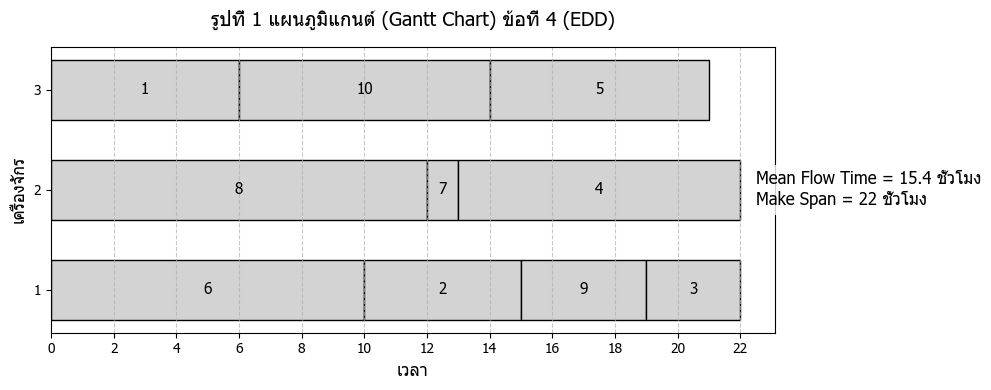

In [11]:
# ข้อมูลตัวอย่าง Parallel Machine (ตาราง 7.16 & 7.19)
data_parallel = pd.DataFrame({
    'งาน': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'เวลาในการผลิต (t)': [6, 5, 3, 9, 7, 10, 1, 12, 4, 8],
    'กำหนดส่ง (d)': [8, 10, 16, 11, 13, 5, 10, 7, 15, 9]
})

print("\n=== ตัวอย่าง 7.9: Parallel SPT+LPT (3 เครื่อง) ===")
df_lpt_result = scheduler.parallel_machine(data_parallel, m_machines=3, rule='EDD')
display(df_lpt_result)

# เรียกใช้ฟังก์ชันแสดงกราฟ
scheduler.plot_parallel_gantt(df_lpt_result, title="รูปที่ 1 แผนภูมิแกนต์ (Gantt Chart) ข้อที่ 4 (EDD)")


# final 2022

## 3

In [12]:
scheduler = JobScheduling()

# ข้อมูลจากตาราง 7.4 และ 7.6
data_single = pd.DataFrame({
    'งาน': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'เวลาในการผลิต (t)': [6, 5, 3, 9, 5, 3, 4, 4, 6, 3],
    'กำหนดส่ง (d)': [9, 9, 15, 14, 12, 5, 7, 10, 15, 8],
    'ความสำคัญ (w)': [250, 400, 240, 320, 600, 750, 1200, 640, 900, 500] # จากตาราง 7.8
})


print("\n=== ตัวอย่าง 7.4: กฎ WSPT ===")
display(scheduler.wspt(data_single))




=== ตัวอย่าง 7.4: กฎ WSPT ===


,งาน,เวลาในการผลิต (t),กำหนดส่ง (d),ความสำคัญ (w),t/w,เวลาที่งานออกจากเครื่อง (C),เวลาส่งไม่ทัน (L),Tardiness (T)
0,7,4,7,1200,0.003333,4,-3,0
1,6,3,5,750,0.004000,7,2,2
2,10,3,8,500,0.006000,10,2,2
3,8,4,10,640,0.006250,14,4,4
4,9,6,15,900,0.006667,20,5,5
5,5,5,12,600,0.008333,25,13,13
6,3,3,15,240,0.012500,28,13,13
7,2,5,9,400,0.012500,33,24,24
8,1,6,9,250,0.024000,39,30,30
9,4,9,14,320,0.028125,48,34,34


## 4


=== ตัวอย่าง 7.9: Parallel EED (3 เครื่อง) ===


,เครื่องจักร,งาน,t
0,1,5,3
1,1,3,12
2,1,1,6
3,1,9,8
4,2,10,13
5,2,7,7
6,2,2,2
7,2,6,5
8,3,8,9
9,3,4,15


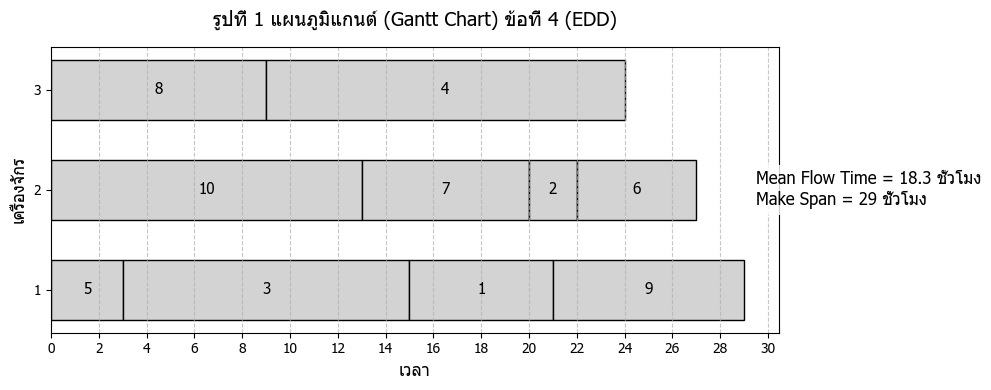

In [ ]:
# ข้อมูลตัวอย่าง Parallel Machine (ตาราง 7.16 & 7.19)
data_parallel = pd.DataFrame({
    'งาน': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'เวลาในการผลิต (t)': [6, 2, 12, 15, 3, 5, 7, 9, 8, 13],
    'กำหนดส่ง (d)': [11, 13, 8, 9, 4, 15, 10, 7, 14, 5]
})
 
print("\n=== ตัวอย่าง 7.9: Parallel EED (3 เครื่อง) ===")
df_lpt_result = scheduler.parallel_machine(data_parallel, m_machines=3, rule='EDD')
display(df_lpt_result)

# เรียกใช้ฟังก์ชันแสดงกราฟ
scheduler.plot_parallel_gantt(df_lpt_result, title="รูปที่ 1 แผนภูมิแกนต์ (Gantt Chart) ข้อที่ 4 (EDD)")


# final 2023

In [16]:
scheduler = JobScheduling()

# ข้อมูลจากตาราง 7.4 และ 7.6
data_single = pd.DataFrame({
    'งาน': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'เวลาในการผลิต (t)': [7, 5, 6, 9, 8, 3, 4, 6, 5, 3],
    'กำหนดส่ง (d)': [25, 9, 20, 44, 30, 10, 7, 28, 13, 12],
    'ความสำคัญ (w)': [280, 400, 288, 500, 480, 600, 1200, 400, 648, 500] # จากตาราง 7.8
})


print("\n=== ตัวอย่าง 7.4: กฎ WSPT ===")
display(scheduler.wspt(data_single))




=== ตัวอย่าง 7.4: กฎ WSPT ===


,งาน,เวลาในการผลิต (t),กำหนดส่ง (d),ความสำคัญ (w),t/w,เวลาที่งานออกจากเครื่อง (C),เวลาส่งไม่ทัน (L),Tardiness (T)
0,7,4,7,1200,0.003333,4,-3,0
1,6,3,10,600,0.005000,7,-3,0
2,10,3,12,500,0.006000,10,-2,0
3,9,5,13,648,0.007716,15,2,2
4,2,5,9,400,0.012500,20,11,11
5,8,6,28,400,0.015000,26,-2,0
6,5,8,30,480,0.016667,34,4,4
7,4,9,44,500,0.018000,43,-1,0
8,3,6,20,288,0.020833,49,29,29
9,1,7,25,280,0.025000,56,31,31



=== ตัวอย่าง 7.9: Parallel EED (3 เครื่อง) ===


,เครื่องจักร,งาน,t
0,1,6,5
1,1,1,6
2,1,4,14
3,2,2,3
4,2,5,3
5,2,7,7
6,2,10,13
7,3,8,6
8,3,9,8
9,3,3,10


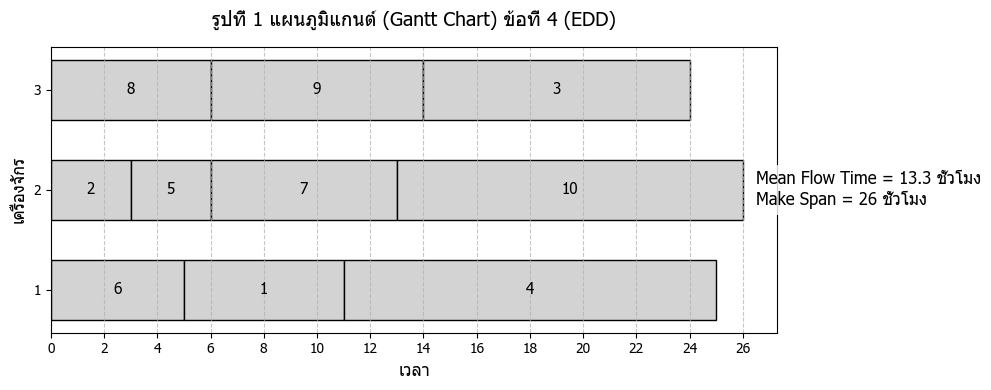

In [18]:
# ข้อมูลตัวอย่าง Parallel Machine (ตาราง 7.16 & 7.19)
data_parallel = pd.DataFrame({
    'งาน': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'เวลาในการผลิต (t)': [6, 3, 10, 14, 3, 5, 7, 6, 8, 13],
    'กำหนดส่ง (d)': [11, 6, 16, 18, 4, 15, 10, 7, 14, 17]
})

print("\n=== ตัวอย่าง 7.9: Parallel EED (3 เครื่อง) ===")
df_lpt_result = scheduler.parallel_machine(data_parallel, m_machines=3, rule='LPT')
display(df_lpt_result)

# เรียกใช้ฟังก์ชันแสดงกราฟ
scheduler.plot_parallel_gantt(df_lpt_result, title="รูปที่ 1 แผนภูมิแกนต์ (Gantt Chart) ข้อที่ 4 (EDD)")


# final 2026

In [21]:
scheduler = JobScheduling()

# ข้อมูลจากตาราง 7.4 และ 7.6
data_single = pd.DataFrame({
    'งาน': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'เวลาในการผลิต (t)': [6, 4, 8, 9, 5, 3, 4, 7, 6, 5],
    'กำหนดส่ง (d)': [30, 42, 23, 13, 47, 38, 50, 55, 24, 10],
    'ความสำคัญ (w)': [1, 2, 3, 1, 2, 3, 2, 1, 2, 3] # จากตาราง 7.8
})


print("\n=== ตัวอย่าง 7.6: กฎ Slack Time (T_NOW = 0) ===")
display(scheduler.slack_time(data_single))




=== ตัวอย่าง 7.6: กฎ Slack Time (T_NOW = 0) ===


,งาน,เวลาในการผลิต (t),กำหนดส่ง (d),ความสำคัญ (w),Slack Time (SL),เวลาที่งานออกจากเครื่อง (C),เวลาส่งไม่ทัน (L),Tardiness (T)
0,4,9,13,1,4.0,9,-4,0
1,10,5,10,3,5.0,14,4,4
2,3,8,23,3,15.0,22,-1,0
3,9,6,24,2,18.0,28,4,4
4,1,6,30,1,24.0,34,4,4
5,6,3,38,3,35.0,37,-1,0
6,2,4,42,2,38.0,41,-1,0
7,5,5,47,2,42.0,46,-1,0
8,7,4,50,2,46.0,50,0,0
9,8,7,55,1,48.0,57,2,2



=== ตัวอย่าง 7.9: Parallel EED (3 เครื่อง) ===


,เครื่องจักร,งาน,t
0,1,5,3
1,1,3,12
2,1,1,6
3,1,9,8
4,2,10,13
5,2,7,7
6,2,2,2
7,2,6,5
8,3,8,9
9,3,4,15


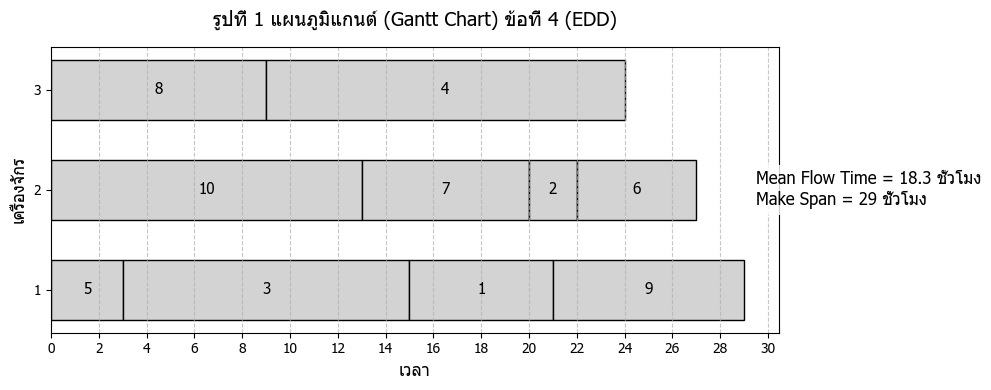

In [22]:
# ข้อมูลตัวอย่าง Parallel Machine (ตาราง 7.16 & 7.19)
data_parallel = pd.DataFrame({
    'งาน': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'เวลาในการผลิต (t)': [6, 2, 12, 15, 3, 5, 7, 9, 8, 13],
    'กำหนดส่ง (d)': [11, 13, 8, 9, 4, 15, 10, 7, 14, 5]
})

print("\n=== ตัวอย่าง 7.9: Parallel EED (3 เครื่อง) ===")
df_lpt_result = scheduler.parallel_machine(data_parallel, m_machines=3, rule='EDD')
display(df_lpt_result)

# เรียกใช้ฟังก์ชันแสดงกราฟ
scheduler.plot_parallel_gantt(df_lpt_result, title="รูปที่ 1 แผนภูมิแกนต์ (Gantt Chart) ข้อที่ 4 (EDD)")
